<div style="font-size:30px;font-weight:700;color:#111827;padding-bottom:8px;margin:18px 0;">
데이터 파이프라인 - Dataset · DataLoader · Transforms
</div>

# FashionMNIST 두 split 로드 + 9-cell sanity 시각화

**목표**: `transform=ToTensor()` 를 건 채 train(60,000) / test(10,000) 두 dataset 을 만들고, 9 개 sample 을 무작위로 뽑아 3×3 그리드로 시각화해 데이터가 의미 있는 모양인지 sanity check 한다.

In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import ToTensor #유틸리티성

In [3]:
training_data = datasets.FashionMNIST(root="data", train=True,  download=True, transform=ToTensor()) #연습할 수 있는 데이터를 가져오기
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor()) #연습할 수 있는 데이터를 가져오기
print(f"len(training_data) = {len(training_data)}")
print(f"len(test_data)     = {len(test_data)}")

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.55MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 138kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.9MB/s]

len(training_data) = 60000
len(test_data)     = 10000


In [4]:
# 한 sample 의 shape 와 squeeze() 효과를 먼저 출력 (시각화 sub-block)
img0, label0 = training_data[0]
print(f"img0.shape         = {tuple(img0.shape)}  (CHW)")
print(f"img0.squeeze().shape = {tuple(img0.squeeze().shape)}  (HW — imshow 용)")
print(f"img0.dtype         = {img0.dtype},  img0.min/max = "
      f"({img0.min().item():.3f}, {img0.max().item():.3f})")
print(f"label0             = {label0}  (정수 클래스 인덱스)")

img0.shape         = (1, 28, 28)  (CHW)
img0.squeeze().shape = (28, 28)  (HW — imshow 용)
img0.dtype         = torch.float32,  img0.min/max = (0.000, 1.000)
label0             = 9  (정수 클래스 인덱스)


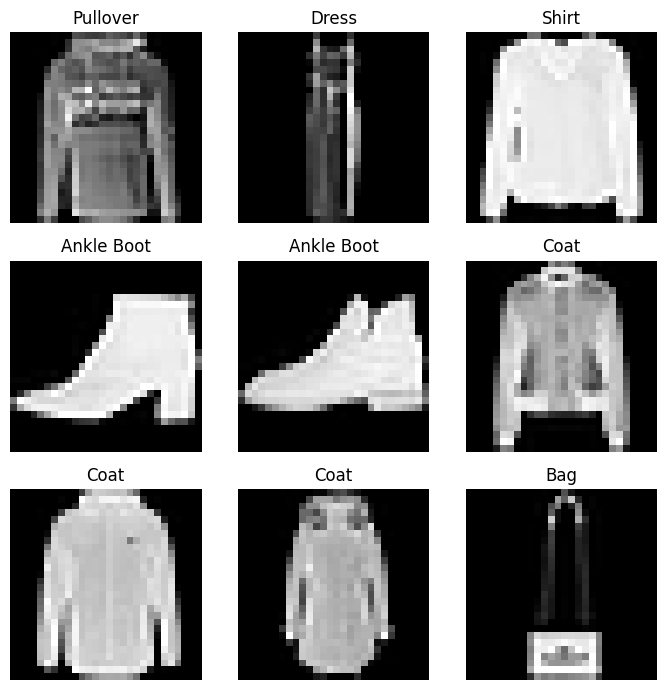

In [5]:
# 9-cell 그리드 시각화
labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"
}
fig = plt.figure(figsize=(7, 7))
for i in range(1, 10):
    idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[idx]
    fig.add_subplot(3, 3, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.tight_layout(); plt.show()

# train / test DataLoader 두 개 생성 (shuffle 비대칭)

**목표**: train 은 `shuffle=True`, test 는 `shuffle=False` 로 두 `DataLoader` 를 만들고 train/test 두 가지가 epoch 시작 시점에 라벨 시퀀스가 어떻게 다르게 나오는지 확인한다.

In [7]:
from torch.utils.data import DataLoader #학습을 위해 DataLoader에 생성

In [9]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True,  num_workers=0) #DataLoader에서 사이즈, 셔플 등 설정
test_dataloader  = DataLoader(test_data,     batch_size=64, shuffle=False, num_workers=0) #test에서는 shuffle을 미사용해 비교, shuffle 사용시 CPU 사용

In [10]:
# 두 DataLoader 의 sampler 타입 확인
print(f"train_dataloader.sampler = {train_dataloader.sampler.__class__.__name__}")
print(f"test_dataloader.sampler  = {test_dataloader.sampler.__class__.__name__}")

train_dataloader.sampler = RandomSampler
test_dataloader.sampler  = SequentialSampler


In [11]:
next(iter(test_dataloader))[0].shape, next(iter(test_dataloader))[1].shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [12]:
# test 에서 첫 배치 라벨 두 번 추출 — 같아야 결정적
y_test_1 = next(iter(test_dataloader))[1][:5]
y_test_2 = next(iter(test_dataloader))[1][:5]
print(f"test 첫 배치 라벨 (1차): {y_test_1.tolist()}")
print(f"test 첫 배치 라벨 (2차): {y_test_2.tolist()}")
print(f"두 번 같음 (test 결정적):  {torch.equal(y_test_1, y_test_2)}")

test 첫 배치 라벨 (1차): [9, 2, 1, 1, 6]
test 첫 배치 라벨 (2차): [9, 2, 1, 1, 6]
두 번 같음 (test 결정적):  True


In [13]:
# train 은 매 epoch 다른 순서 — 두 번 호출 비교
y_train_1 = next(iter(train_dataloader))[1][:5]
y_train_2 = next(iter(train_dataloader))[1][:5]
print(f"train 첫 배치 라벨 (1차): {y_train_1.tolist()}")
print(f"train 첫 배치 라벨 (2차): {y_train_2.tolist()}")
print(f"두 번 같음 (train shuffle): {torch.equal(y_train_1, y_train_2)}  ← False 가 정상")

train 첫 배치 라벨 (1차): [9, 9, 3, 6, 8]
train 첫 배치 라벨 (2차): [8, 3, 3, 2, 2]
두 번 같음 (train shuffle): False  ← False 가 정상


# 첫 배치 shape sanity check + `len(loader)` vs `len(loader.dataset)`

**목표**: `next(iter(train_dataloader))` 로 첫 배치를 꺼내 shape 가 `(64, 1, 28, 28)` / `(64,)` 인지 확인하고, batch 수와 sample 수 두 길이를 동시에 출력해 혼동을 막는다.

In [14]:
X, y = next(iter(train_dataloader))
print(f"Feature batch shape: {X.size()}")
print(f"Labels  batch shape: {y.size()}")
print(f"X.dtype = {X.dtype},  y.dtype = {y.dtype}")
print(f"X.min/max = ({X.min().item():.3f}, {X.max().item():.3f})  ← ToTensor() 가 [0,1] 로")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels  batch shape: torch.Size([64])
X.dtype = torch.float32,  y.dtype = torch.int64
X.min/max = (0.000, 1.000)  ← ToTensor() 가 [0,1] 로


len(train_dataloader)         = 938     ← batch 수 = ceil(60000 / 64)
len(train_dataloader.dataset) = 60000  ← sample 수


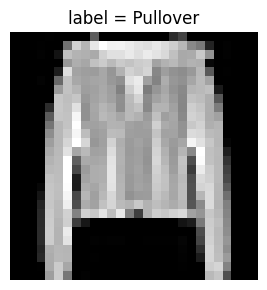

In [15]:
print(f"len(train_dataloader)         = {len(train_dataloader)}     "
      f"← batch 수 = ceil(60000 / 64)")
print(f"len(train_dataloader.dataset) = {len(train_dataloader.dataset)}  "
      f"← sample 수")

# 첫 batch 의 0 번째 sample 만 시각화 (CHW → HW)
plt.figure(figsize=(3, 3))
plt.imshow(X[0].squeeze(), cmap="gray")
plt.title(f"label = {labels_map[y[0].item()]}")
plt.axis("off"); plt.tight_layout(); plt.show()


# 보조 예제 B 데이터 준비: 더미 PNG 10 장 + CSV 라벨

**목표**: `tempfile.mkdtemp()` 아래에 10 장의 28×28 grayscale PNG 와 `labels.csv` 를 만들어 `CustomImageDataset` 의 입력 형태를 흉내내고, 데이터가 어떻게 디스크에 있는지를 먼저 시각화한다.

In [17]:
#빈 이미지 제작용 변수 제작
import os
import csv
import tempfile
import pandas as pd
from PIL import Image

In [18]:
tmpdir = tempfile.mkdtemp(prefix="data_imgs_")
img_dir = os.path.join(tmpdir, "imgs")
os.makedirs(img_dir, exist_ok=True)
ann_path = os.path.join(tmpdir, "labels.csv")

In [19]:
img_dir, ann_path

('/tmp/data_imgs_h5jn3v9f/imgs', '/tmp/data_imgs_h5jn3v9f/labels.csv')

In [20]:
with open(ann_path, "w", newline="") as f:
    w = csv.writer(f)
    for i in range(10):
        name = f"img_{i:02d}.png"
        # 밝기가 i 에 비례하는 28×28 grayscale 더미 이미지
        Image.new("L", (28, 28), color=i * 20).save(os.path.join(img_dir, name))
        w.writerow([name, i % 5])   # 5 클래스 라벨 (0~4)
print(f"tmpdir       = {tmpdir}")
print(f"파일 수     = {len(os.listdir(img_dir))}")
os.listdir(img_dir)

tmpdir       = /tmp/data_imgs_h5jn3v9f
파일 수     = 10


['img_09.png',
 'img_00.png',
 'img_01.png',
 'img_03.png',
 'img_05.png',
 'img_08.png',
 'img_04.png',
 'img_02.png',
 'img_07.png',
 'img_06.png']

In [21]:
# 시각화 sub-block: 디스크의 CSV head + 첫 두 PNG 미리 보기
labels_df = pd.read_csv(ann_path, header=None, names=["filename", "label"])
labels_df.head(3)

,filename,label
0,img_00.png,0
1,img_01.png,1
2,img_02.png,2


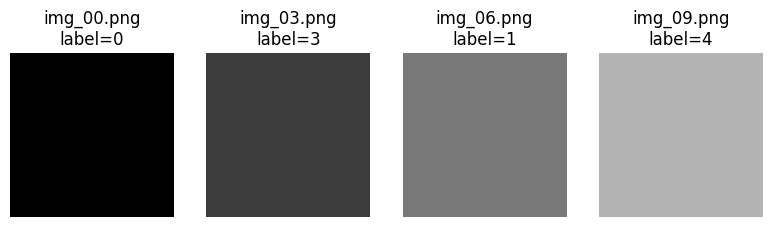

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(8, 2.2))
for i, idx in enumerate([0, 3, 6, 9]):
    fn = labels_df.iloc[idx]["filename"]
    axes[i].imshow(Image.open(os.path.join(img_dir, fn)), cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(f"{fn}\nlabel={labels_df.iloc[idx]['label']}")
    axes[i].axis("off")
plt.tight_layout(); plt.show()

# `CustomImageDataset` 3-메서드 구현 + 동작 검증

**목표**: `__init__` / `__len__` / `__getitem__` 세 메서드만으로 `Dataset` 서브클래스를 작성하고, `len(ds)` 와 `ds[0]` 두 호출의 출력으로 계약이 지켜졌는지 확인한다.

In [23]:
from torch.utils.data import Dataset
from torchvision.io import decode_image

In [27]:
class CustomImageDataset(Dataset): #입맛대로 제작 가능, GPU로 들어가기 전에 제작 필요
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file, header=None, names=["filename", "label"])
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)           # uint8 [0, 255]
        label = int(self.img_labels.iloc[idx, 1])
        if self.transform:        image = self.transform(image)
        if self.target_transform: label = self.target_transform(label)
        return image, label #데이터와 정답은 리턴 필요

In [28]:
ds = CustomImageDataset(ann_path, img_dir)
print(f"len(ds) = {len(ds)}")

len(ds) = 10


In [29]:
img, label = ds[0]
print(f"ds[0] -> img.shape = {tuple(img.shape)}, dtype = {img.dtype}, label = {label}")

ds[0] -> img.shape = (1, 28, 28), dtype = torch.uint8, label = 0


In [30]:
# DataLoader 로 묶어 첫 배치 확인
loader = DataLoader(ds, batch_size=4, shuffle=False)
X_b, y_b = next(iter(loader))
print(f"batch X.shape = {tuple(X_b.shape)},  y = {y_b.tolist()}")

batch X.shape = (4, 1, 28, 28),  y = [0, 1, 2, 3]
